# IOMB Tutorial for CAMAS Early Career School

This notebook is a tutorial for installing and running ILAMB on NERSC Perlmutter, then extending that workflow to IOMB benchmarking.

## Reference pages used in building this tutorial

Official ILAMB install information:  
https://www.ilamb.org/doc/install.html

Official IOMB tutorial:  
https://www.ilamb.org/doc/running_iomb.html

ILAMB3 tutorial page with ESGF/model-data examples:  
https://ilamb3.readthedocs.io/en/latest/tutorial_01_run.html#model-data

`intake-esgf` documentation:  
https://intake-esgf.readthedocs.io/en/latest/beginner.html


<div style="background-color:#f2f2f2; padding:14px;border:1px solid #d9d9d9; border-radius:6px;">

## If you have opened this notebook, steps 1-3 have already been completed. These instructions are included here only for completeness.


# Step 1 — Log in to NERSC
To use Perlmutter, you must first have an active NERSC account and access to Perlmutter.
### Option A — NERSC Jupyter (This is what we are doing for this tutorial today)
Go to:
https://jupyter.nersc.gov
and log in with your NERSC credentials.
Click the **START** button on a login node.

### Option B — SSH from your local machine
From a terminal on your own computer:
```bash
ssh username@perlmutter.nersc.gov
```
Replace `username` with your NERSC username.

### What happens when you log in?

You land on a **login node**. This is the right place for:
- editing files
- setting up environments
- preparing runs
- lightweight commands
- launching Jupyter sessions
It is **not** the place for heavy computation.

# Step 2 — Open a Terminal in NERSC JupyterLab

Inside JupyterLab:

1. Click on the $PSCRATCH folder in the upper left then open the launcher tab if it is not already open.
2. Click **Terminal**. This should open a terminal interface and you should be in your own scratch directory. i.e. mine is /pscratch/sd/g/georgina  


# Step 3 — Copy the CAMAS folder to your scratch space

The **CAMAS** folder has files you need to complete the tutorial and this tutorial notebook. You need to copy this folder into your scratch area so you can work on your own copy of the files.

<b>
cp -rf /global/cfs/cdirs/ntrain5/CAMAS $PSCRATCH
</b>


</div>

# Step 4 — Create the ILAMB project directory

We now want to create a **project working directory** that will contain model configuration files, observational data, and output from benchmarking comparisons. 

Run this bash cell:


In [9]:
%%bash
mkdir -p $PSCRATCH/ILAMB_runs

# Step 5 — Set the ILAMB root

ILAMB_ROOT is an environment variable /relative paths used by ILAMB workflows to define a root area for data download inputs/outputs.

**In Jupyter notebook bash cells, the environment does not persist from one cell to the next, so later cells will repeat this command.**

Run this bash cell:


In [10]:
%%bash
export ILAMB_ROOT=$PSCRATCH/ILAMB_runs
echo "ILAMB_ROOT=$ILAMB_ROOT"


ILAMB_ROOT=/pscratch/sd/g/georgina/ILAMB_runs


# Step 6 — Load the Unified Environment

NERSC provides a **unified** software environment so that common scientific Python tools and related dependencies are already configured in a way that works on Perlmutter.

This is helpful because it reduces the amount of manual dependency management you need to do yourself.

**In Jupyter notebook bash cells, the environment does not persist from one cell to the next, so later cells will repeat the setup they need.**

Run this bash cell:


In [11]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
echo "Unified environment loaded."


Unified environment loaded.


### What this does
This command configures your shell session so that:
- the unified Python/software stack is available
- standard scientific libraries are found
- the environment is more consistent with E3SM-related workflows


# Step 7 — Get the Ocean Benchmarking (Observational) Data
ILAMB was originally developed for land-model benchmarking, but the package is generic enough to support other model-reference comparisons.
The ocean benchmarking workflow is commonly referred to as **IOMB**. Before running benchmarks of ocean model output you need to fetch the IOMB benchmark data.

IOMB reference datasets give you:

- a curated reference-data collection
- a standardized starting point for ocean benchmarking

Run this bash cell:


In [12]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
conda activate /global/cfs/cdirs/ntrain5/ILAMB
export ILAMB_ROOT=$PSCRATCH/ILAMB_runs/
yes y | ilamb-fetch --remote_root https://www.ilamb.org/IOMB-Data



Comparing remote location:

	https://www.ilamb.org/IOMB-Data

To local location:

	/pscratch/sd/g/georgina/ILAMB_runs/

All your data is up-to-date and clean.



This creates a `DATA` directory under your ILAMB_runs project area that contains sub-directories for each oceanographic reference dataset:

Boyer,   GLODAP2.2022,   Gruber,   MODISAqua,  OCIM,   SeaWIFS, and   WOA2018 


# Step 8 — Get some Ocean Model Data
Now we need some model data to 'benchmark' against the observations. Eventually you will likely want to use your own model data, but for this tutorial we will use data from the Earth System Grid Federation (ESGF) catalog.

ESGF is a globally distributed network of data servers that lets you find, access, and download climate and Earth system model data (e.g., CMIP).

ESGF is not required for ILAMB itself but gives access to model output we will use in the tutorial. The `intake-esgf` package is useful for searching ESGF catalogs and locating model data programmatically.


### Install the `intake-esgf` package
This downloads the package and places its files in a location where Python can find them.
Run this bash cell:


In [13]:
%%bash
cd $PSCRATCH

In [14]:
%pip install --user -U globus-sdk intake-esgf

  Using cached globus_sdk-4.5.0-py3-none-any.whl.metadata (2.1 kB)
DEPRECATION: fair-research-login 0.2.6 has a non-standard dependency specifier globus-sdk<4.0.0>=1.5.0. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of fair-research-login or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Note: you may need to restart the kernel to use updated packages.


### ***RESTART THE KERNEL***
This makes sure that the newly installed package is recognized by the notebook.
<b> From top menu kernel -> restart kernel </b>

### Import the `intake-esgf` package

In [1]:
import os
import intake_esgf

# Set the cache location BEFORE using ESGF (byt default it downloads to your $HOME where there is not much space)
intake_esgf.conf["local_cache"] = [os.path.join(os.environ["PSCRATCH"], "esgf_cache")]

# The ESGF catalog provides a searchable interface to available model data, allowing us to query for specific variables, experiments, and models and retrieve the corresponding file locations.
from intake_esgf import ESGFCatalog
cat = ESGFCatalog()
print(f"ESGFCatalog object created")


ESGFCatalog object created


# Step 9 — Search the catalog for information about your variable of interest. </b>

You can search by:
- variable
- experiment
- table
- source/model
- member/ensemble

<b> For example: here we will search for chlorophyll in historical simulations. </b>


In [2]:
search = cat.search(variable_id="chl", experiment_id="historical")
search

   Searching indices:   0%|          |0/1 [       ?index/s]

Summary information for 686 results:
mip_era                                                     [CMIP6]
activity_drs                                                 [CMIP]
institution_id    [CCCma, CMCC, CNRM-CERFACS, CSIRO, EC-Earth-Co...
source_id         [CanESM5-1, CanESM5-CanOE, CanESM5, CMCC-ESM2,...
experiment_id                                          [historical]
member_id         [r10i1p1f1, r10i1p2f1, r11i1p1f1, r11i1p2f1, r...
table_id                                                [Oyr, Omon]
variable_id                                                   [chl]
grid_label                                            [gn, gr1, gr]
dtype: object

The above gave 686 model results. 

<b> You can narrow the search further, i.e. below we ask for files with monthly output from the CanESM5 model: </b>


In [3]:
search = cat.search(
    variable_id="chl",
    experiment_id="historical",
    table_id="Omon",
    source_id="CanESM5-1",
    member_id="r1i1p1f1",
)
search


   Searching indices:   0%|          |0/1 [       ?index/s]

Summary information for 1 results:
mip_era                [CMIP6]
activity_drs            [CMIP]
institution_id         [CCCma]
source_id          [CanESM5-1]
experiment_id     [historical]
member_id           [r1i1p1f1]
table_id                [Omon]
variable_id              [chl]
grid_label                [gn]
dtype: object

This should give you a single model that matches the specified criteria.


<b> Convert the ESGF catalog result into a dictionary of file paths. These paths are then used in the ILAMB model-data setup. </b>


In [4]:
paths = search.to_path_dict()
print(paths)

Get file information:   0%|          |0/1 [       ?index/s]

{'chl': [PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429/chl_Omon_CanESM5-1_historical_r1i1p1f1_gn_185001-186012.nc'), PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429/chl_Omon_CanESM5-1_historical_r1i1p1f1_gn_186101-187012.nc'), PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429/chl_Omon_CanESM5-1_historical_r1i1p1f1_gn_187101-188012.nc'), PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429/chl_Omon_CanESM5-1_historical_r1i1p1f1_gn_188101-189012.nc'), PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429/chl_Omon_CanESM5-1_historical_r1i1p1f1_gn_189101-190012.nc'), PosixPath('/pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v

# Step 10 — Activate the ILAMB Environment

The ILAMB environment is a conda environment that defines a specific set of Python packages and versions (e.g., numpy, matplotlib, mpi4py) required for ILAMB to run correctly.


A dedicated conda environment helps:

    avoid dependency conflicts
    make troubleshooting easier
    keep the install reproducible
    avoid modifying a shared or default Python environment


<div style="background-color:#f2f2f2; padding:14px; border:1px solid #d9d9d9; border-radius:6px;">

If you were running ILAMB on a different machine you would create your own ILAMB environment from a YAML file and activate it before running ILAMB, rather than relying on a shared pre-installed environment. There is an example YAML file in the CAMAS directorty.

You would run it like: conda env create -f CAMAS/ilamb.yml --prefix $PSCRATCH/ILAMB

**Note:** For efficiency and consistency across users, we will use the **pre-installed ILAMB environment** available in the shared `ntrain` directory.

</div>

In [5]:
%%bash
# Load the Unified Environment  (required on Perlmutter)
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh

# Activate the shared ILAMB environment
conda activate /global/cfs/cdirs/ntrain5/ILAMB

echo "ILAMB environment activated."
which python


ILAMB environment activated.
/global/cfs/cdirs/ntrain5/ILAMB/bin/python


# Step 11 — Checking the ILAMB Install

With the ILAMB environment activated, run the following command to check that ILAMB is available.

Because this is a new `%%bash` cell, the environment activation commands are repeated here on purpose.


In [6]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
conda activate /global/cfs/cdirs/ntrain5/ILAMB

# Set a non-interactive plotting backend so ILAMB can run outside the Jupyter notebook environment without crashing.
export MPLBACKEND=Agg

# Run ILAMB-help to confirm installation.
ilamb-run --help


MPI startup(): FI_PSM3_UUID was not generated, please set it to avoid possible resources ownership conflicts between MPI processes
usage: ilamb-run [-h] [--model_root root] [--config config]
                 [--models m [m ...]] [--model_year y0 yf [y0 yf ...]]
                 [--study_limits y0 yf [y0 yf ...]]
                 [--confrontations c [c ...]] [--regions r [r ...]] [--clean]
                 [--disable_logging] [-q] [--filter filter] [--regex regex]
                 [--build_dir build_dir]
                 [--define_regions DEFINE_REGIONS [DEFINE_REGIONS ...]]
                 [--model_setup MODEL_SETUP [MODEL_SETUP ...]] [--skip_plots]
                 [--rel_only] [--mem_per_pair MEM] [--title title]
                 [--rmse_score_basis basis] [--df_errs df_errs]
                 [-g GLOBAL_REGION]

Runs an ILAMB study.

options:
  -h, --help            show this help message and exit
  --model_root root     root at which to search for models
  --config config       pat

If this prints the ILAMB help text, the installation is working.

Note: You may see an MPI warning about FI_PSM3_UUID. This is harmless in this context and can be safely ignored.


# Step 12. Setting up a IOMB Benchmark 

Now that we have ocean model output and observational data to compare it to, we need to setup two files which the ILAMB package will use to initiate a benchmark study.  

The CAMAS/CONFIG folder contains an example .cfg and an example .yaml file. Copy the whole directory to your Ilamb project directry. 

Run this bash cell:


In [7]:
%%bash
cp -rf $PSCRATCH/CAMAS/CONFIG $PSCRATCH/ILAMB_runs


## The configure File
ILAMB uses configure file which specifies which variables we are interested in and whcih <b> observational</b> data set to use for the benchmark.

The tutorial uses a simple config file `iomb_tutorial.cfg` which will compare model output to GLOBAP chl-a data. 

The CONFIG folder also contains a full tempate `iomb_tutorial.cfg` of variables and datasets that will be useful if you are putting together your own benchmark run.

Open the `iomb_tutorial.cfg` file by navigating to ILAMB_runs/CONFIG with the File Explorer on the left and double clicking it. 

`iomb_tutorial.cfg` is reproduce below for easy viewing:

The path in the file specifies where ILAMB should look for the observational data you downloaded.

<b> Edit the source to match your own scratch path. </b>

source = "/pscratch/sd/<span style="color:green;font-weight:bold;">g/georgina</span>/ILAMB_runs/DATA/GLODAP2.2022/chla.nc" 



```ini
########################################################

[h1: Ecosystems]
bgcolor = "#ECFFE6"

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

[h2: Chlorophyll]
variable       = "chla"
alternate_vars = "chl"
depths = 5.5
skip_rmse = True
skip_cycle = True

[GLODAP2.2022]
source = "/pscratch/sd/g/georgina/ILAMB_runs/DATA/GLODAP2.2022/chla.nc"
skip_rmse = True
skip_cycle = True
table_unit = "1e-6 kg m-3"
plot_unit = "1e-6 kg m-3"

```



##  The model YAML file

The YAML file is where you specify which <b>model</b> we are interested in.

If we had downloaded multiple models/versions of a model you could include them all here. 

Open the `models_tutorial.yaml` file by navigating to ILAMB_runs/CONFIG with the File Explorer on the left and double clicking it. 

`models_tutorial.yaml` is reproduce below for easy viewing:

The path in the file specifies where ILAMB should look for the model data you downloaded.

<b> Edit the path to match your own scratch path. </b>

 path: /pscratch/sd/<span style="color:green;font-weight:bold;">g/georgina</span>/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429

```yaml
CanESM5:
  modelname: CanESM5
  color: "#393b79"
  path:  /pscratch/sd/g/georgina/esgf_cache/CMIP6/CMIP/CCCma/CanESM5-1/historical/r1i1p1f1/Omon/chl/gn/v20190429
```

## Run the model

Ensure that you still have the ILAMB environment activated.

Run this bash cell:


In [8]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
cd $PSCRATCH/ILAMB_runs

# WARNING: This will remove your existing _build directory.
# But will help clear build files from previous runs that can complicate things.
rm -rf _build

conda activate /global/cfs/cdirs/ntrain5/ILAMB
export ILAMB_ROOT=$PSCRATCH/ILAMB_runs
echo $ILAMB_ROOT
export MPLBACKEND=Agg

ilamb-run --config CONFIG/iomb_tutorial.cfg --model_setup CONFIG/models_tutorial.yaml --clean


/pscratch/sd/g/georgina/ILAMB_runs
MPI startup(): FI_PSM3_UUID was not generated, please set it to avoid possible resources ownership conflicts between MPI processes

Setting up model results from CONFIG/models_tutorial.yaml

                                        CanESM5-1

Parsing config file CONFIG/iomb_tutorial.cfg...

                    Chlorophyll5.50m/GLODAP2.2022 Initialized

Running model-confrontation pairs...

                    Chlorophyll5.50m/GLODAP2.2022 CanESM5-1            Completed  0:04:29

Finishing post-processing which requires collectives...

                    Chlorophyll5.50m/GLODAP2.2022 CanESM5-1            Completed  0:00:04

Completed in  0:04:34



# Step 13. Viewing ILAMB Output 

A sucesfull run of ILAMB generates a directory of results which by default is called _build. 
  
This is where it writes log files, png image files etc. 

In [ ]:
%%bash
cd $SCRATCH/ILAMB_runs/_build
ls -lrt

## ILAMB is designed to allow interactive viewing of the results on a webpage.

When running the ILAMB package on NERSC's Perlmutter supercomputer, the local HTTP server (e.g., `http://0.0.0.0:8000/`) is hosted on the remote machine—not your local computer. To access the visual output in a browser on your local machine, you need to set up SSH port forwarding. Here's how:

## Connect a terminal with SSH Port Forwarding

<b> From a local terminal </b> use the following command to log in to Perlmutter and forward the port:

### The following commands should be pasted into yor local ssh terminal:

```bash
ssh -L 8000:localhost:8000 georgina@perlmutter.nersc.gov
```

This tells SSH to forward traffic from port 8000 on your local computer to port 8000 on the remote Perlmutter machine. This creates a secure tunnel.

### Once connected to Perlmutter paste the following commands into the ssh terminal:

```bash

cd $SCRATCH/ILAMB_runs/_build

source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh

# Activate the shared ILAMB environment
conda activate /global/cfs/cdirs/ntrain5/ILAMB

python -m http.server 8000
```


should see something like this:

```text
Serving HTTP on 0.0.0.0 port 8000 (http://0.0.0.0:8000/) ...
```


### Open ILAMB Output in Your Local Browser

Open a web browser (Chrome, Safari, Firefox, etc.) and go to:

```text
http://localhost:8000/
```

**You should now see the ILAMB output! 🎉**


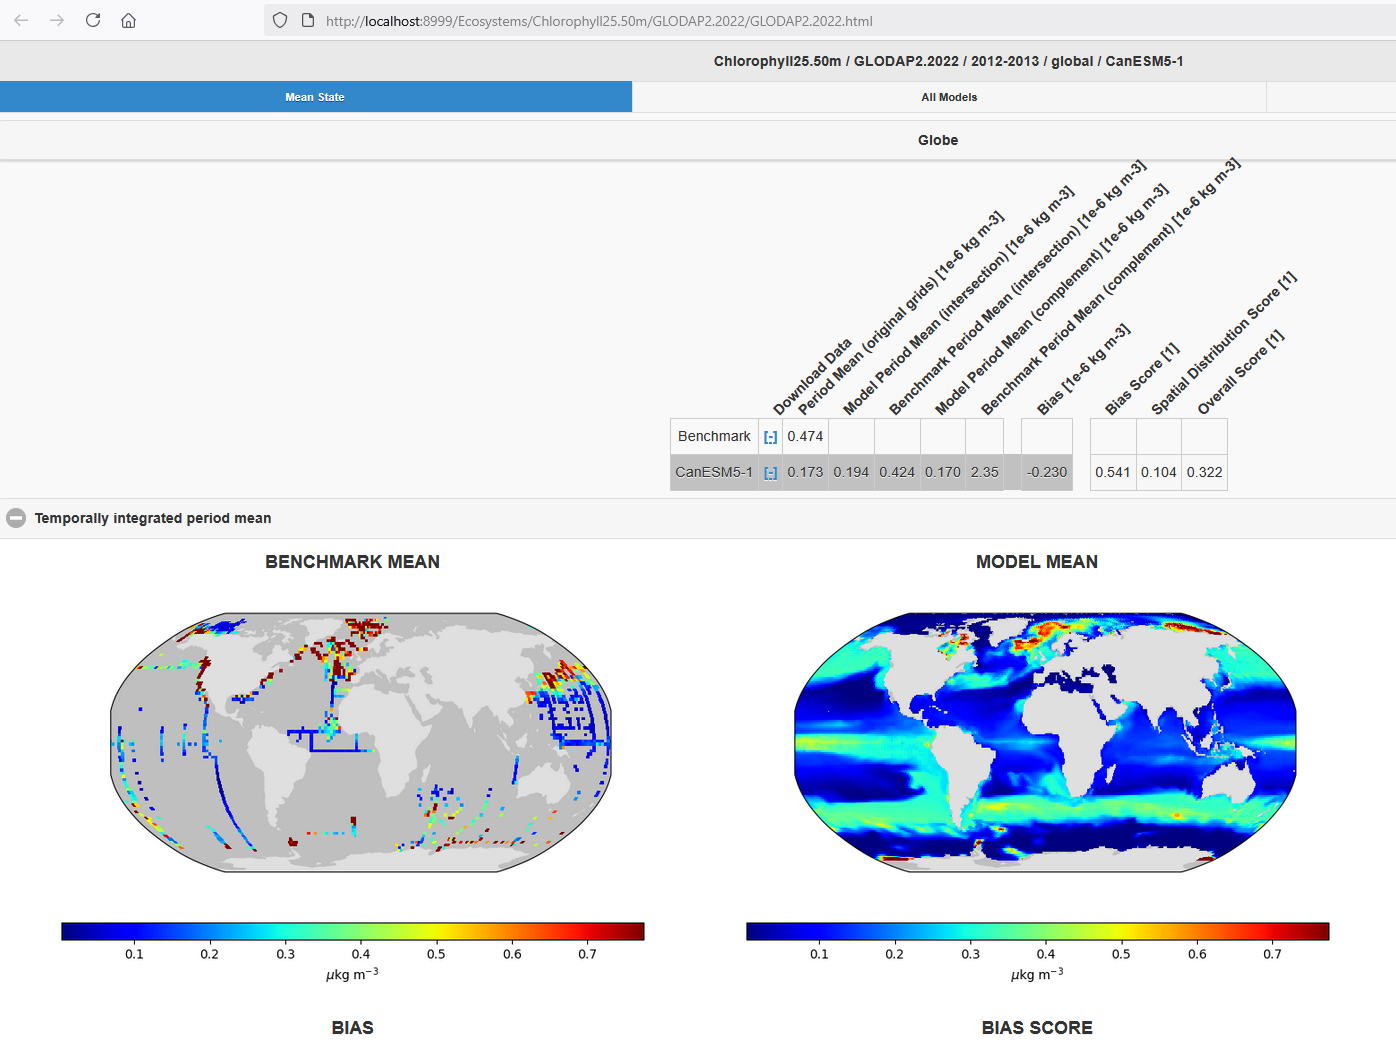

<b> Convert the ESGF catalog result into a dictionary of file paths. This time the path is an existing directory on Perlmutter. </b>


### Below are two slightly more complex benchmarks you can try and set up.

NOTE: Each time we delete the _build directory. This is to prevent ILAMB getting confused. If you were setting up multiple benchmark experiments you would make seperate project directories for each i.e. instead of ILAMB_runs you could have ILAMB_Can, ILAMB_regional etc.

# Challenge 1: Compare IOMB Benchmarks from multiple models

Re-run the benchmark but include an additional model. The additional model I selected is already housed on Perlmutter so we dont need to download it.

Run this bash cell:


In [ ]:
search = cat.search(
    variable_id="chl",
    experiment_id="historical",
    table_id="Omon",
    source_id="CanESM5-CanOE",
     member_id="r3i1p2f1",
)
search

This should give you a single models that matches the specified criteria.


<b> Convert the ESGF catalog result into a dictionary of file paths. This time the path is an existing directory on Perlmutter. </b>


In [ ]:
paths = search.to_path_dict()
print(paths)

<b> Now re-run ILAMB. <b> NOTE the updated model yaml file </b>
You will need to update the path to your CanESM5-1 model like you did previously.


In [ ]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
cd $PSCRATCH/ILAMB_runs

# WARNING: This will remove your existing _build directory.
# But will help clear build files from previous runs that can complicate things.
rm -rf _build

conda activate /global/cfs/cdirs/ntrain5/ILAMB
export ILAMB_ROOT=$PSCRATCH/ILAMB_runs
echo $ILAMB_ROOT
export MPLBACKEND=Agg

ilamb-run --config CONFIG/iomb_tutorial.cfg --model_setup CONFIG/models_tutorial-challenge.yaml --clean


# Challenge 2: Regional IOMB Benchmarks 

Re-run the benchmark but return regional metrics. 

ILAMB does have pre-defined 'land' regions but we can define our own regions that span ocean areas. The IOMB configuration can parse either a text file (bounding box) or a netcdf with integer mask.  

Run this bash cell:


In [ ]:
%%bash
source /global/common/software/e3sm/anaconda_envs/load_latest_e3sm_unified_pm-cpu.sh
cd $PSCRATCH/ILAMB_runs

# WARNING: This will remove your existing _build directory.
# But will help clear build files from previous runs that can complicate things.
rm -rf _build

conda activate /global/cfs/cdirs/ntrain5/ILAMB
export ILAMB_ROOT=$PSCRATCH/ILAMB_runs
echo $ILAMB_ROOT
export MPLBACKEND=Agg

ilamb-run \
--config CONFIG/iomb_tutorial.cfg \
--model_setup CONFIG/models_tutorial.yaml \
--define_regions CONFIG/ArcticRegions.txt \
--regions global chukchi beaufort \
--clean
